# 新最小構成 v2.6A：No-DiffPool + Phase-A Speed Optimizations

## v2.6 → v2.6A の変更点

### 【Phase-A高速化】
1. **患者データの事前Tensor化**: 学習中の `torch.tensor(...)` 連発を削減
2. **患者単位の一括device転送**: ループ内の転送オーバーヘッドを削減
3. **欠損補完のスキップ**: 欠損がない時点では `state_decoder` を呼ばない
4. **Transformerトークン上限を設定可能化**: `max_transformer_tokens` を追加

### 【モデルの意味は維持】
5. タスク定義（次ステップ予測 + AE予測）は変更しない
6. No-DiffPool構成と評価枠組みは維持

---


---
## セル1: Google Driveマウント
---

In [ ]:
# [UNCHANGED] Google Driveマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## セル2: ライブラリインポート & デバイス設定
---

In [ ]:
# [UNCHANGED] ライブラリインポート
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from collections import defaultdict
import os
import json
from datetime import datetime
from tqdm import tqdm
# TF32有効化（Ampere/Hopper GPUで高速化）
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


#A100用
try:
    torch.set_float32_matmul_precision("high")
except:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# [MODIFIED] チェックポイント保存ディレクトリ
CHECKPOINT_DIR = "/content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


device: cuda
Checkpoint directory: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext


---
## セル3: torch-geometric インストール
---

In [ ]:
# [MODIFIED] torch-geometricはv2.6 No-DiffPoolで不要
print("torch-geometric installation skipped (No-DiffPool)")


torch-geometric installation skipped (No-DiffPool)


---
## セル4: 設定パラメータ
---

In [ ]:
# [MODIFIED] 設定パラメータ
# [FIX-v2.6A] Phase-A高速化向け設定を追加

CONFIG = {
    # === データパス ===
    "data_path": "/content/drive/MyDrive/世界モデル_最終課題/TimeSeries_processed.csv",

    # === カラム名 ===
    "id_col": "PatientID",
    "time_col": "time_days",
    "chemo_col": "ChemoAdministered",

    # === AE判定用カラム ===
    "ae_cols": ["WBC", "Neutr", "GOT(AST)", "GPT(ALT)", "CRP"],
    "ae_thresholds": {
        "WBC": ("<", 2.0),
        "Neutr": ("<", 1.0),
        "GOT(AST)": (">", 100.0),
        "GPT(ALT)": (">", 90.0),
        "CRP": (">", 5.0),
    },

    # === 時間設定（週単位） ===
    "days_per_week": 7.0,
    "dt_int": 1.0,
    "tau": 1.0,
    "ae_window_days": 7.0,

    # === モデル次元 ===
    "hidden_dim": 64,
    "node_feature_dim": 5,
    "attn_dim": 16,
    "encoder_hidden_dim": 16,
    "latent_dim": 48,
    "transformer_heads": 2,
    "ffn_mult": 4,
    # Phase-A高速化: Transformer入力トークン上限（s_token含む）
    "max_transformer_tokens": 256,

    # === ODE設定 ===
    "ode_hidden_dim": 128,

    # === 学習設定 ===
    "num_epochs": 50,
    "lr": 1e-3,
    "lambda_ae": 1.0,
    "lambda_halflife": 0.01,
    "train_ratio": 0.7,
    "val_ratio": 0.15,

    # 巨大ギャップ区間は不安定化防止のためリセット
    "max_delta_week": 52.0,

    # === その他 ===
    "seed": 42,
}

print("=" * 50)
print("CONFIG (v2.6A no-diffpool phase-A)")
print("=" * 50)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


CONFIG (v2.6A no-diffpool phase-A)
  data_path: /content/drive/MyDrive/世界モデル_最終課題/TimeSeries_processed.csv
  id_col: PatientID
  time_col: time_days
  chemo_col: ChemoAdministered
  ae_cols: ['WBC', 'Neutr', 'GOT(AST)', 'GPT(ALT)', 'CRP']
  ae_thresholds: {'WBC': ('<', 2.0), 'Neutr': ('<', 1.0), 'GOT(AST)': ('>', 100.0), 'GPT(ALT)': ('>', 90.0), 'CRP': ('>', 5.0)}
  days_per_week: 7.0
  dt_int: 1.0
  tau: 1.0
  ae_window_days: 7.0
  hidden_dim: 64
  node_feature_dim: 5
  attn_dim: 16
  encoder_hidden_dim: 16
  latent_dim: 48
  transformer_heads: 2
  ffn_mult: 4
  max_transformer_tokens: 256
  ode_hidden_dim: 128
  num_epochs: 50
  lr: 0.001
  lambda_ae: 1.0
  lambda_halflife: 0.01
  train_ratio: 0.7
  val_ratio: 0.15
  max_delta_week: 52.0
  seed: 42


---
## セル5: データ読み込み & 前処理
### [FIX-v2.6] 標準化はセル6.5で実施、Chemo変換を堅牢化
---

In [ ]:
# [MODIFIED] データ読み込み
# [FIX-v2.5] 標準化はセル6.5で行う（train患者のみで統計計算）
# [FIX-v2.5] ChemoAdministered変換を堅牢化

df = pd.read_csv(CONFIG["data_path"])
print(f"データ読み込み完了: {len(df)} 行, {df[CONFIG['id_col']].nunique()} 患者")

# =============================================================
# [FIX-v2.5] ChemoAdministered変換を堅牢化
# 変更前: map({True:1, False:0, 'True':1, 'False':0})
#         → 元データが0/1数値だと全部NaN→0になる
# 変更後: bool/文字列/数値を全て安全に吸収
# =============================================================
def safe_chemo_convert(val):
    """True/False, 'True'/'False', 1/0, 1.0/0.0 を全て安全に0/1に変換"""
    if pd.isna(val):
        return 0
    if isinstance(val, bool):
        return int(val)
    if isinstance(val, (int, float)):
        return 1 if val != 0 else 0
    # 文字列の場合
    s = str(val).lower().strip()
    return 1 if s in ('true', '1', '1.0') else 0

df[CONFIG["chemo_col"]] = df[CONFIG["chemo_col"]].apply(safe_chemo_convert)
print(f"ChemoAdministered分布: {df[CONFIG['chemo_col']].value_counts().to_dict()}")

# 特徴量カラムの特定
exclude_cols = [
    CONFIG["id_col"],
    CONFIG["time_col"],
    CONFIG["chemo_col"]
]
feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
    and not c.startswith("met_")
    and not c.startswith("tx_")
]

F = len(feature_cols)
print(f"特徴量数 F: {F}")
print(f"特徴量カラム: {feature_cols[:10]}... (先頭10個)")

ae_col_indices = [feature_cols.index(c) for c in CONFIG["ae_cols"] if c in feature_cols]
print(f"AE判定用カラムのインデックス: {ae_col_indices}")

# [FIX-v2.5] 生データを保持（AEラベル判定用）
df_raw = df.copy()
print("\n[FIX-v2.5] df_raw（生値）を保持")
print("[FIX-v2.5] 標準化はセル6.5で実施（train患者のみで統計計算）")

# [FIX-v2.5] 欠損マスクを作成（標準化前に作成することが重要）
mask_df = df[feature_cols].notna().astype(float)
print(f"欠損率（全体平均）: {(1 - mask_df.values.mean()) * 100:.2f}%")

データ読み込み完了: 34555 行, 1000 患者
ChemoAdministered分布: {0: 26423, 1: 8132}
特徴量数 F: 42
特徴量カラム: ['APTT', 'A/G', 'ALB', 'INR', 'PT_perc', 'PT_sec', 'TP', 'PREALB', 'WBC', 'RBC']... (先頭10個)
AE判定用カラムのインデックス: [8, 20, 29, 30, 39]

[FIX-v2.5] df_raw（生値）を保持
[FIX-v2.5] 標準化はセル6.5で実施（train患者のみで統計計算）
欠損率（全体平均）: 7.87%


---
## セル6: 患者単位でのデータ分割（層化）
---

In [ ]:
# [UNCHANGED] 患者単位でのデータ分割

np.random.seed(CONFIG["seed"])

patient_ids = df[CONFIG["id_col"]].unique()
print(f"総患者数: {len(patient_ids)}")

patient_has_chemo = {}
for pid in patient_ids:
    patient_df = df[df[CONFIG["id_col"]] == pid]
    patient_has_chemo[pid] = patient_df[CONFIG["chemo_col"]].sum() > 0

pids_with_chemo = [pid for pid, has in patient_has_chemo.items() if has]
pids_without_chemo = [pid for pid, has in patient_has_chemo.items() if not has]
print(f"介入あり患者: {len(pids_with_chemo)}, 介入なし患者: {len(pids_without_chemo)}")

def stratified_split(pids, train_ratio, val_ratio, seed):
    np.random.seed(seed)
    pids = np.array(pids)
    np.random.shuffle(pids)

    n = len(pids)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_pids = pids[:n_train]
    val_pids = pids[n_train:n_train + n_val]
    test_pids = pids[n_train + n_val:]

    return train_pids.tolist(), val_pids.tolist(), test_pids.tolist()

train_chemo, val_chemo, test_chemo = stratified_split(
    pids_with_chemo, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["seed"]
)
train_no_chemo, val_no_chemo, test_no_chemo = stratified_split(
    pids_without_chemo, CONFIG["train_ratio"], CONFIG["val_ratio"], CONFIG["seed"] + 1
)

train_pids = train_chemo + train_no_chemo
val_pids = val_chemo + val_no_chemo
test_pids = test_chemo + test_no_chemo

print(f"\n分割結果:")
print(f"  Train: {len(train_pids)} 患者 (介入あり: {len(train_chemo)}, なし: {len(train_no_chemo)})")
print(f"  Val:   {len(val_pids)} 患者 (介入あり: {len(val_chemo)}, なし: {len(val_no_chemo)})")
print(f"  Test:  {len(test_pids)} 患者 (介入あり: {len(test_chemo)}, なし: {len(test_no_chemo)})")

split_info = {
    "train_pids": train_pids,
    "val_pids": val_pids,
    "test_pids": test_pids,
}
with open(os.path.join(CHECKPOINT_DIR, "split_info.json"), "w") as f:
    json.dump({k: [int(x) for x in v] for k, v in split_info.items()}, f)
print(f"\n分割情報を保存: {os.path.join(CHECKPOINT_DIR, 'split_info.json')}")

総患者数: 1000
介入あり患者: 1000, 介入なし患者: 0

分割結果:
  Train: 700 患者 (介入あり: 700, なし: 0)
  Val:   150 患者 (介入あり: 150, なし: 0)
  Test:  150 患者 (介入あり: 150, なし: 0)

分割情報を保存: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/split_info.json


---
## セル6.5: 標準化（train患者のみで統計計算）+ 検算
### [FIX-v2.6] 新規セル - データリーク完全排除
---

In [ ]:
# =============================================================
# [FIX-v2.5] 新規セル: 標準化（train患者のみで統計計算）
# =============================================================
# このセルはセル6（患者分割）の直後に実行すること
#
# 変更前（v2）: 全患者でmean/stdを計算 → テストデータリーク
# 変更後（v2.5）: train患者のみでmean/stdを計算 → リークなし
# =============================================================

print("=" * 60)
print("[FIX-v2.5] 標準化（train患者のみで統計計算）")
print("=" * 60)

# train患者の行だけを抽出
train_mask = df[CONFIG["id_col"]].isin(train_pids)
train_df = df.loc[train_mask, feature_cols]

print(f"Train患者の行数: {len(train_df)}")

# train患者のみでmean/stdを計算（NaN無視）
feature_mean = train_df.mean(skipna=True)
feature_std = train_df.std(skipna=True, ddof=0)  # StandardScaler互換

# ゼロ割防止（stdが0またはNaNの列は1に置換）
feature_std = feature_std.replace(0, 1.0)
feature_std = feature_std.fillna(1.0)

# meanがNaNの列は0に置換（train全欠損の列）
feature_mean = feature_mean.fillna(0.0)

print(f"統計計算完了（train患者 {len(train_pids)} 人のみ使用）")

# 全データ（train+val+test）を標準化
df_scaled = (df[feature_cols] - feature_mean) / feature_std

# 標準化後にNaNを0（=平均）に置換
df_scaled = df_scaled.fillna(0.0)

# dfを更新
df[feature_cols] = df_scaled

print("[FIX-v2.5] 標準化完了")
print(f"  - 統計はtrain患者のみから計算")
print(f"  - val/testはtrain統計で変換（リークなし）")

# 統計情報を保存
scaling_info = {
    "mean": feature_mean.to_dict(),
    "std": feature_std.to_dict(),
    "train_pids_used": len(train_pids),
}

# AE5項目の統計を表示
print(f"\n標準化統計（AE判定用5項目、train患者のみ）:")
for col in CONFIG["ae_cols"]:
    if col in feature_cols:
        print(f"  {col}: mean={feature_mean[col]:.3f}, std={feature_std[col]:.3f}")

# =============================================================
# [FIX-v2.5] 検算: リークが本当に消えたかを確認
# =============================================================

print("\n" + "=" * 60)
print("[検算] スケーリングの健全性チェック")
print("=" * 60)

# (A) train患者のスケーリング後平均・標準偏差を確認
train_mask_rows = df[CONFIG["id_col"]].isin(train_pids)
train_scaled = df.loc[train_mask_rows, feature_cols].values
train_masks = mask_df.loc[train_mask_rows].values

# マスク適用（観測値のみ）
train_scaled_masked = np.where(train_masks == 1, train_scaled, np.nan)

# 列ごとの平均と標準偏差
check_mean = np.nanmean(train_scaled_masked, axis=0)
check_std = np.nanstd(train_scaled_masked, axis=0, ddof=0)

print(f"Train患者（観測値のみ）のスケーリング後統計:")
print(f"  平均: min={np.min(check_mean):.6f}, max={np.max(check_mean):.6f}, mean={np.mean(check_mean):.6f}")
print(f"  標準偏差: min={np.min(check_std):.4f}, max={np.max(check_std):.4f}, mean={np.mean(check_std):.4f}")

# 期待値: mean ≈ 0, std ≈ 1
if np.abs(np.mean(check_mean)) < 0.01 and np.abs(np.mean(check_std) - 1.0) < 0.1:
    print("  ✓ 正常: mean≈0, std≈1 を確認")
else:
    print("  ⚠ 警告: 統計が期待値から外れています。処理順序を確認してください。")

# (B) mask_df が標準化後に作り直されていないか確認
mask_sum = mask_df.values.sum()
mask_total = mask_df.values.size
mask_ratio = mask_sum / mask_total

print(f"\n欠損マスクの確認:")
print(f"  観測あり(mask=1): {int(mask_sum):,} / {mask_total:,} ({mask_ratio*100:.2f}%)")

if mask_ratio > 0.99:
    print("  ⚠ 警告: mask_dfがほぼ全て1です。fillna後に作り直していませんか？")
else:
    print("  ✓ 正常: 欠損が適切に記録されています")

# (C) val/test患者のスケーリング後統計（リークチェック）
val_mask_rows = df[CONFIG["id_col"]].isin(val_pids)
val_scaled = df.loc[val_mask_rows, feature_cols].values
val_masks = mask_df.loc[val_mask_rows].values
val_scaled_masked = np.where(val_masks == 1, val_scaled, np.nan)

val_check_mean = np.nanmean(val_scaled_masked, axis=0)
val_check_std = np.nanstd(val_scaled_masked, axis=0, ddof=0)

print(f"\nVal患者（観測値のみ）のスケーリング後統計:")
print(f"  平均: min={np.min(val_check_mean):.4f}, max={np.max(val_check_mean):.4f}, mean={np.mean(val_check_mean):.4f}")
print(f"  標準偏差: min={np.min(val_check_std):.4f}, max={np.max(val_check_std):.4f}, mean={np.mean(val_check_std):.4f}")
print("  （trainと若干異なるのが正常。完全一致はリークの兆候）")

print("\n" + "=" * 60)
print("[検算完了] 上記に警告がなければ、リークは解消されています")
print("=" * 60)

[FIX-v2.5] 標準化（train患者のみで統計計算）
Train患者の行数: 23794
統計計算完了（train患者 700 人のみ使用）
[FIX-v2.5] 標準化完了
  - 統計はtrain患者のみから計算
  - val/testはtrain統計で変換（リークなし）

標準化統計（AE判定用5項目、train患者のみ）:
  WBC: mean=4.606, std=2.199
  Neutr: mean=2.230, std=1.767
  GOT(AST): mean=25.360, std=20.683
  GPT(ALT): mean=27.784, std=34.569
  CRP: mean=0.649, std=1.993

[検算] スケーリングの健全性チェック
Train患者（観測値のみ）のスケーリング後統計:
  平均: min=-0.000000, max=0.000000, mean=-0.000000
  標準偏差: min=1.0000, max=1.0000, mean=1.0000
  ✓ 正常: mean≈0, std≈1 を確認

欠損マスクの確認:
  観測あり(mask=1): 1,337,087 / 1,451,310 (92.13%)
  ✓ 正常: 欠損が適切に記録されています

Val患者（観測値のみ）のスケーリング後統計:
  平均: min=-0.1736, max=0.2063, mean=0.0089
  標準偏差: min=0.5560, max=1.4606, mean=1.0340
  （trainと若干異なるのが正常。完全一致はリークの兆候）

[検算完了] 上記に警告がなければ、リークは解消されています


---
## セル7: 患者データ構造の作成
---

In [ ]:
# [MODIFIED] 患者ごとのデータ構造を作成
# [FIX-v2.6A] Phase-A: numpyに加えてTensorを事前作成（高速化）


def build_patient_data(df_scaled, df_raw, patient_ids, feature_cols, mask_df, config):
    patient_data = {}

    for pid in patient_ids:
        pdf_scaled = df_scaled[df_scaled[config["id_col"]] == pid].sort_values(config["time_col"])
        indices = pdf_scaled.index.tolist()
        pdf_raw = df_raw.loc[indices]

        times = pdf_scaled[config["time_col"]].values.astype(np.float32)
        times_week = (times / config["days_per_week"]).astype(np.float32)
        features = pdf_scaled[feature_cols].values.astype(np.float32)
        masks = mask_df.loc[indices].values.astype(np.float32)
        chemo = pdf_scaled[config["chemo_col"]].values.astype(np.int32)

        # Phase-A: 欠損がある観測点だけ補完するためのフラグ
        has_missing = (masks < 0.5).any(axis=1)

        # Phase-A: TensorをCPU側で事前作成（必要ならpin memory）
        times_week_t = torch.from_numpy(times_week)
        features_t = torch.from_numpy(features)
        masks_t = torch.from_numpy(masks)
        chemo_t = torch.from_numpy(chemo.astype(np.int64))

        if torch.cuda.is_available():
            times_week_t = times_week_t.pin_memory()
            features_t = features_t.pin_memory()
            masks_t = masks_t.pin_memory()
            chemo_t = chemo_t.pin_memory()

        # AEラベルの計算（生値から直接判定）
        ae_labels = {}

        for i in range(len(times)):
            if chemo[i] == 1:
                t_intervention = times[i]
                future_indices = [
                    j for j in range(i + 1, len(times))
                    if times[j] - t_intervention <= config["ae_window_days"]
                ]

                if len(future_indices) == 0:
                    ae_labels[i] = (None, False)
                else:
                    ae_occurred = False
                    label_valid = False

                    for j in future_indices:
                        raw_row = pdf_raw.iloc[j]

                        ae_mask_ok = True
                        for col in config["ae_cols"]:
                            if col in feature_cols and pd.isna(raw_row[col]):
                                ae_mask_ok = False
                                break

                        if ae_mask_ok:
                            label_valid = True
                            for col, (op, thresh) in config["ae_thresholds"].items():
                                if col in feature_cols:
                                    raw_val = raw_row[col]
                                    if op == "<" and raw_val < thresh:
                                        ae_occurred = True
                                        break
                                    elif op == ">" and raw_val > thresh:
                                        ae_occurred = True
                                        break

                            if ae_occurred:
                                break

                    ae_labels[i] = (int(ae_occurred), True) if label_valid else (None, False)

        patient_data[pid] = {
            "times": times,
            "times_week": times_week,
            "features": features,
            "masks": masks,
            "chemo": chemo,
            # Phase-A追加
            "times_week_t": times_week_t,
            "features_t": features_t,
            "masks_t": masks_t,
            "chemo_t": chemo_t,
            "has_missing": has_missing,
            # 既存
            "ae_labels": ae_labels,
            "n_obs": len(times),
        }

    return patient_data


print("患者データ構造を構築中...")

train_data = build_patient_data(df, df_raw, train_pids, feature_cols, mask_df, CONFIG)
val_data = build_patient_data(df, df_raw, val_pids, feature_cols, mask_df, CONFIG)
test_data = build_patient_data(df, df_raw, test_pids, feature_cols, mask_df, CONFIG)


def count_ae_labels(patient_data):
    total_interventions = 0
    valid_ae_labels = 0
    ae_positive = 0
    for pid, data in patient_data.items():
        for i, (label, valid) in data["ae_labels"].items():
            total_interventions += 1
            if valid:
                valid_ae_labels += 1
                if label == 1:
                    ae_positive += 1
    return total_interventions, valid_ae_labels, ae_positive


print("\n=== データ統計 ===")
for name, data in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    total_obs = sum(d["n_obs"] for d in data.values())
    total_int, valid_ae, ae_pos = count_ae_labels(data)
    print(f"{name}: {len(data)}患者, {total_obs}観測点, "
          f"{total_int}介入点, {valid_ae}有効AEラベル (うちAE=1: {ae_pos})")


患者データ構造を構築中...

=== データ統計 ===
Train: 700患者, 23794観測点, 5678介入点, 1943有効AEラベル (うちAE=1: 438)
Val: 150患者, 4869観測点, 1184介入点, 425有効AEラベル (うちAE=1: 92)
Test: 150患者, 5892観測点, 1270介入点, 442有効AEラベル (うちAE=1: 99)


---
## セル8: CrossTimeAttention
---

In [ ]:
# [UNCHANGED] CrossTimeAttention

class CrossTimeAttention(nn.Module):
    """
    t-1とtの検査項目間のCrossAttentionで隣接行列Aを構築
    A = attn(x_{t-1}, x_t) → x_{t+1}を予測
    """
    def __init__(self, in_dim, attn_dim):
        super().__init__()
        self.q = nn.Linear(in_dim, attn_dim, bias=False)
        self.k = nn.Linear(in_dim, attn_dim, bias=False)

    def forward(self, h_prev, h_curr):
        Q = self.q(h_prev)
        K = self.k(h_curr)
        A = Q @ K.T / np.sqrt(Q.size(-1))
        return torch_F.softmax(A, dim=1)

print("CrossTimeAttention 定義完了")

CrossTimeAttention 定義完了


---
## セル9: No-DiffPool Placeholder
---

In [ ]:
# [MODIFIED] DiffPoolItemNetはv2.6で削除
# [FIX-v2.6] No-DiffPool最小構成のため、このセルはプレースホルダ
print("DiffPoolItemNet は v2.6 (No-DiffPool) で未使用")


DiffPoolItemNet は v2.6 (No-DiffPool) で未使用


---
## セル10: ItemGraphEncoder
---

In [ ]:
# [MODIFIED] SimpleXtEncoder (No-DiffPool / No Cross-Time Attention)
# [FIX-v3] 観測時点の x_t のみを MLP で潜在表現 s_t に写像

class ItemGraphEncoder(nn.Module):
    """
    v3 Encoder:
    - 入力は x_t のみ（x_{t-1} や Attention を使わない）
    - DiffPool / Cross-Time Attention なし
    - s_t = MLP(x_t)

    既存コード互換のため forward シグネチャは維持する。
    """
    def __init__(self, latent_dim, F_features, attn_dim=16, hidden_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(F_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x_curr, x_prev=None, mask_curr=None, dt=None):
        # x_curr: (F,) or (B,F)
        s = self.net(x_curr)
        return s, None

print("SimpleXtEncoder 定義完了（v3: x_t only MLP）")


SimpleXtEncoder 定義完了（v3: x_t only MLP）


---
## セル11: ODE関数
### [FIX-v2.6] Softsign + 減衰スカラーc(t) + 半減期パラメータ化
---

In [ ]:
# [MODIFIED] ODE関数
# [FIX-v2.5] ReLU → Softsign（ODE安定化）
# [FIX-v2.5] 減衰スカラー c(t) + 半減期パラメータ化

class Softsign(nn.Module):
    """tanh より飽和が緩やかで勾配が残りやすい"""
    def forward(self, x):
        return x / (1 + torch.abs(x))


class ResidualMLP(nn.Module):
    """Residual MLP with Softsign（ODE安定化のため）"""
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            Softsign(),
            nn.Linear(hidden_dim, hidden_dim),
            Softsign(),
            nn.Linear(hidden_dim, dim),
        )
        self.ln = nn.LayerNorm(dim)

    def forward(self, x):
        return self.ln(x + self.net(x))


class ODEFunc(nn.Module):
    """
    ODE関数: dh/dt = f_0(h) + gate(c) * f_1(h)
             dc/dt = -γ * c （指数減衰）

    [FIX-v2.5] 変更点:
    - 介入効果 a を直接使わず、減衰スカラー c(t) を使用
    - c は投与時に +1 され、時間とともに指数減衰
    - 半減期 T_{1/2} は学習可能（初期値1週、弱い正則化）
    """
    def __init__(self, hidden_dim, ode_hidden_dim):
        super().__init__()
        self.f0 = ResidualMLP(hidden_dim, ode_hidden_dim)
        self.f1 = ResidualMLP(hidden_dim, ode_hidden_dim)
        self.velocity = nn.Linear(hidden_dim, hidden_dim)
        nn.init.xavier_uniform_(self.velocity.weight, gain=0.1)

        # 半減期パラメータ（学習可能）
        # softplus(0.541) ≈ 1.0 → 初期半減期 ≈ 1週
        self.log_halflife_raw = nn.Parameter(torch.tensor(0.541))
        self.epsilon = 0.01

    @property
    def halflife(self):
        """半減期 T_{1/2}（週単位、正の値）"""
        return torch.nn.functional.softplus(self.log_halflife_raw) + self.epsilon

    @property
    def gamma(self):
        """減衰率 γ = ln(2) / T_{1/2}"""
        return 0.693 / self.halflife

    def forward(self, h, c):
        """
        h: (hidden_dim,) - 隠れ状態
        c: scalar tensor - 薬効の強さ（減衰する）

        Returns:
            dh_dt: (hidden_dim,) - hの時間微分
            dc_dt: scalar - cの時間微分
        """
        h0 = self.f0(h)
        h1 = self.f1(h)

        # sigmoid(c) でゲート（0〜1に収まる）
        gate = torch.tanh(c)
        h_combined = h0 + gate * h1

        dh_dt = self.velocity(h_combined)
        dc_dt = -self.gamma * c  # 指数減衰

        return dh_dt, dc_dt

    def halflife_regularization(self):
        """半減期の正則化項（1週から離れすぎないように）"""
        target = torch.tensor(1.0, device=self.log_halflife_raw.device)
        return (torch.log(self.halflife) - torch.log(target)) ** 2


print("Softsign, ResidualMLP, ODEFunc 定義完了")
print("  - Softsign: ReLUより安定")
print("  - ODEFunc: 減衰スカラー c(t) + 学習可能な半減期")

Softsign, ResidualMLP, ODEFunc 定義完了
  - Softsign: ReLUより安定
  - ODEFunc: 減衰スカラー c(t) + 学習可能な半減期


---
## セル12: ODE Solver（RK2）
### [FIX-v2.6] h と c の両方を積分
---

In [ ]:
# [MODIFIED] ODE Solver (RK2/Midpoint Method)
# [FIX-v2.5] h と c の両方を積分

class RK2Solver:
    """
    RK2（中点法）によるODE積分

    [FIX-v2.5] 変更点:
    - h だけでなく c（薬効スカラー）も同時に積分
    """
    def __init__(self, ode_func, dt_int=1.0):
        self.ode_func = ode_func
        self.dt_int = dt_int

    def step(self, h, c, dt):
        """1ステップのRK2積分（h, c 両方を更新）"""
        dh1, dc1 = self.ode_func(h, c)

        h_mid = h + (dt / 2) * dh1
        c_mid = c + (dt / 2) * dc1

        dh2, dc2 = self.ode_func(h_mid, c_mid)

        h_next = h + dt * dh2
        c_next = c + dt * dc2

        return h_next, c_next

    def integrate(self, h, c, delta_t):
        """h, c を delta_t（週単位）だけ積分"""
        if delta_t <= 0:
            return h, c

        n_steps = int(delta_t / self.dt_int)
        remainder = delta_t - n_steps * self.dt_int

        for _ in range(n_steps):
            h, c = self.step(h, c, self.dt_int)

        if remainder > 1e-6:
            h, c = self.step(h, c, remainder)

        return h, c

    def integrate_with_samples(self, h, c, delta_t, tau):
        """
        τ間隔でサンプリングしながら積分

        Returns:
            samples: list of h - サンプル列
            h_final: 最終状態
            c_final: 最終の薬効スカラー
        """
        if delta_t <= 0:
            return [h], h, c

        samples = []
        current_time = 0.0

        while current_time < delta_t:
            next_sample_time = current_time + tau

            if next_sample_time >= delta_t:
                remaining = delta_t - current_time
                h, c = self.integrate(h, c, remaining)
                samples.append(h)
                break
            else:
                h, c = self.integrate(h, c, tau)
                samples.append(h)
                current_time = next_sample_time

        return samples, h, c


print("RK2Solver 定義完了（FIX-v2.5: h, c 両方を積分）")

RK2Solver 定義完了（FIX-v2.5: h, c 両方を積分）


---
## セル13: GRU同化セル
### [FIX-v2.6] c の更新を追加（投与時に +1）
---

In [ ]:
# [MODIFIED] GRU同化セル
# [FIX-v2.5] c の更新を追加（投与時に +1）

class AssimilationCell(nn.Module):
    """
    観測点での状態更新（同化）

    [FIX-v2.5] 変更点:
    - h^+ = GRUCell(h^-, concat(s_i, c))
    - c^+ = c^- + a_i （投与時に薬効 +1）
    """
    def __init__(self, hidden_dim, obs_dim):
        super().__init__()
        # 入力に c を含める
        self.gru = nn.GRUCell(obs_dim + 1, hidden_dim)

    def forward(self, h_minus, c_minus, s, a):
        """
        h_minus: (hidden_dim,) - ODE積分後の隠れ状態
        c_minus: scalar tensor - ODE積分後の薬効スカラー
        s: (obs_dim,) - 観測表現（DiffPool出力）
        a: int or float - 介入フラグ (0 or 1)

        Returns:
            h_plus: (hidden_dim,) - 同化後の隠れ状態
            c_plus: scalar tensor - 同化後の薬効（投与時に+1）
        """
        # 投与時に c に +1（薬効の蓄積）
        c_plus = c_minus + float(a)

        # GRU入力に c_plus を含める
        if torch.is_tensor(c_plus):
            c_tensor = c_plus.unsqueeze(0)
        else:
            c_tensor = torch.tensor([c_plus], device=s.device)
        u = torch.cat([s, c_tensor], dim=0)

        h_plus = self.gru(u.unsqueeze(0), h_minus.unsqueeze(0))

        # c_plus を tensor として返す
        if not torch.is_tensor(c_plus):
            c_plus = torch.tensor(c_plus, device=s.device, dtype=torch.float)

        return h_plus.squeeze(0), c_plus


print("AssimilationCell 定義完了（FIX-v2.5: c の更新を追加）")

AssimilationCell 定義完了（FIX-v2.5: c の更新を追加）


---
## セル14: WindowTransformer
---

In [ ]:
# [UNCHANGED] WindowTransformer

class WindowTransformer(nn.Module):
    def __init__(self, dim, heads=2, max_len=512):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            dim, heads, batch_first=True
        )
        self.ln = nn.LayerNorm(dim)
        self.pos_emb = nn.Embedding(max_len, dim)

    def forward(self, x):
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        pos = self.pos_emb(pos).unsqueeze(0)

        x = x + pos
        #ここの重みは軽量化のために出力しないようにします。
        out, attn_w = self.attn(x, x, x, need_weights=False)
        return self.ln(x + out), None

print("WindowTransformer 定義完了")

WindowTransformer 定義完了


---
## セル15: TimeFFN
---

In [ ]:
# [UNCHANGED] TimeFFN

class TimeFFN(nn.Module):
    def __init__(self, dim, hidden_mult=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * hidden_mult),
            nn.ReLU(),
            nn.Linear(dim * hidden_mult, dim),
        )
        self.ln = nn.LayerNorm(dim)

    def forward(self, x):
        return self.ln(x + self.net(x))

print("TimeFFN 定義完了")

TimeFFN 定義完了


---
## セル16: 予測ヘッド
---

In [ ]:
# [UNCHANGED] 予測ヘッド

class PredictionHead(nn.Module):
    def __init__(self, dim, out_dim):
        super().__init__()
        self.head = nn.Linear(dim, out_dim)

    def forward(self, h_time):
        h_last = h_time[:, -1, :]
        return self.head(h_last).squeeze(0)


class StateDecoder(nn.Module):
    def __init__(self, hidden_dim, out_dim):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, h):
        return self.decoder(h)


class AEHead(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Linear(dim // 2, 1),
            #Sigmoid()　AMPを使うために削除しています。
        )

    def forward(self, h_time):
        h_last = h_time[:, -1, :]
        return self.head(h_last).squeeze()

print("PredictionHead, StateDecoder, AEHead 定義完了")

PredictionHead, StateDecoder, AEHead 定義完了


---
## セル17: 統合モデル
### [FIX-v2.6] 減衰スカラー c(t) の管理を追加
---

In [ ]:
# [MODIFIED] 統合モデル
# [FIX-v2.6A] Phase-A: Transformerトークン上限設定を追加

class IntegratedModel(nn.Module):
    """
    ODE-RNN + SimpleXtEncoder + No-DiffPool + Transformer の統合モデル
    """
    def __init__(self, config, F):
        super().__init__()
        self.config = config
        self.F = F

        hidden_dim = config["hidden_dim"]
        latent_dim = config.get("latent_dim", 48)
        encoder_hidden_dim = config.get("encoder_hidden_dim", 16)

        self.encoder = ItemGraphEncoder(
            latent_dim=latent_dim,
            F_features=F,
            attn_dim=config["attn_dim"],
            hidden_dim=encoder_hidden_dim
        )

        self.ode_func = ODEFunc(
            hidden_dim=hidden_dim,
            ode_hidden_dim=config["ode_hidden_dim"]
        )
        self.ode_solver = RK2Solver(self.ode_func, dt_int=config["dt_int"])

        self.assimilation = AssimilationCell(
            hidden_dim=hidden_dim,
            obs_dim=latent_dim
        )

        self.proj_s = nn.Linear(latent_dim, hidden_dim)

        self.transformer = WindowTransformer(
            dim=hidden_dim,
            heads=config["transformer_heads"]
        )
        self.ffn = TimeFFN(hidden_dim, config["ffn_mult"])

        self.pred_head = PredictionHead(hidden_dim, F)
        self.state_decoder = StateDecoder(hidden_dim, F)
        self.ae_head = AEHead(hidden_dim)

        self.h0 = nn.Parameter(torch.zeros(hidden_dim), requires_grad=False)
        self.c0 = 0.0

    def _get_token_budget(self):
        model_cap = self.transformer.pos_emb.num_embeddings
        cfg_cap = int(self.config.get("max_transformer_tokens", model_cap))
        token_cap = min(model_cap, cfg_cap)
        return max(2, token_cap)

    def forward_interval(self, h_plus, c_plus, s_token, delta_t_week):
        h_samples, h_final, c_final = self.ode_solver.integrate_with_samples(
            h_plus, c_plus, delta_t_week, self.config["tau"]
        )

        h_samples_tensor = torch.stack(h_samples)

        token_cap = self._get_token_budget()
        max_samples = token_cap - 1

        if h_samples_tensor.size(0) > max_samples:
            idx = torch.linspace(
                0, h_samples_tensor.size(0) - 1,
                steps=max_samples,
                device=h_samples_tensor.device
            ).long()
            h_samples_tensor = h_samples_tensor.index_select(0, idx)

        tokens = torch.cat([
            s_token.unsqueeze(0),
            h_samples_tensor
        ], dim=0).unsqueeze(0)

        h_time, _ = self.transformer(tokens)
        h_time = self.ffn(h_time)

        pred = self.pred_head(h_time)

        return pred, h_final, c_final

    def forward_ae(self, h_plus, c_plus, s_token):
        ae_window_week = self.config["ae_window_days"] / self.config["days_per_week"]

        h_samples, _, _ = self.ode_solver.integrate_with_samples(
            h_plus, c_plus, ae_window_week, self.config["tau"]
        )

        h_samples_tensor = torch.stack(h_samples)

        token_cap = self._get_token_budget()
        max_samples = token_cap - 1

        if h_samples_tensor.size(0) > max_samples:
            idx = torch.linspace(
                0, h_samples_tensor.size(0) - 1,
                steps=max_samples,
                device=h_samples_tensor.device
            ).long()
            h_samples_tensor = h_samples_tensor.index_select(0, idx)

        tokens = torch.cat([
            s_token.unsqueeze(0),
            h_samples_tensor
        ], dim=0).unsqueeze(0)

        h_time, _ = self.transformer(tokens)
        h_time = self.ffn(h_time)

        ae_prob = self.ae_head(h_time)

        return ae_prob

    def get_halflife_reg(self):
        return self.ode_func.halflife_regularization()

    def get_halflife(self):
        return self.ode_func.halflife.item()


print("IntegratedModel 定義完了（FIX-v2.6A: Phase-A token cap対応）")


IntegratedModel 定義完了（FIX-v2.6A: Phase-A token cap対応）


---
## セル18: 学習関数
### [FIX-v2.6] 減衰スカラー c(t) の管理を追加
---

In [ ]:
# [MODIFIED] 学習関数
# [FIX-v2.6A] Phase-A: Tensor事前化 + 欠損補完スキップ


def _get_patient_tensors(patient_data, device):
    """患者データをデバイスへ一括転送して返す（Phase-A高速化）"""
    if "features_t" in patient_data:
        features = patient_data["features_t"].to(device, non_blocking=True)
        masks = patient_data["masks_t"].to(device, non_blocking=True)
        times_week = patient_data["times_week_t"].to(device, non_blocking=True)
        chemo = patient_data["chemo_t"].to(device, non_blocking=True)
    else:
        features = torch.tensor(patient_data["features"], dtype=torch.float32, device=device)
        masks = torch.tensor(patient_data["masks"], dtype=torch.float32, device=device)
        times_week = torch.tensor(patient_data["times_week"], dtype=torch.float32, device=device)
        chemo = torch.tensor(patient_data["chemo"], dtype=torch.long, device=device)

    has_missing = patient_data.get("has_missing")
    if has_missing is None:
        has_missing = (patient_data["masks"] < 0.5).any(axis=1)

    return times_week, features, masks, chemo, has_missing


def train_one_patient(model, patient_data, optimizer, config, device):
    """1患者の学習"""
    n_obs = patient_data["n_obs"]
    ae_labels = patient_data["ae_labels"]

    if n_obs < 2:
        return 0.0, 0.0, 0, 0, [], 0

    times_week, features, masks, chemo, has_missing = _get_patient_tensors(patient_data, device)

    h = model.h0.clone()
    c = torch.tensor(model.c0, dtype=torch.float, device=device)

    loss_pred_total = 0.0
    loss_ae_total = 0.0
    n_pred = 0
    n_ae = 0
    ae_preds = []
    n_gap_resets = 0

    x_prev = features[0]

    for i in range(n_obs):
        x_curr = features[i]
        mask_curr = masks[i]
        a_i = int(chemo[i].item())

        if i == 0:
            dt = 0.0
        else:
            dt = float((times_week[i] - times_week[i - 1]).item())

        # 欠損がある時点だけ補完（Phase-A高速化）
        if i > 0 and has_missing[i]:
            x_tilde = model.state_decoder(h)
            x_input = mask_curr * x_curr + (1 - mask_curr) * x_tilde
        else:
            x_input = x_curr

        x_prev_input = x_input if i == 0 else x_prev

        s_i, _ = model.encoder(x_input, x_prev_input, mask_curr, dt)
        s_token = model.proj_s(s_i)

        h_plus, c_plus = model.assimilation(h, c, s_i, a_i)

        if i < n_obs - 1:
            delta_t = float((times_week[i + 1] - times_week[i]).item())

            if delta_t > config.get("max_delta_week", 1e9):
                n_gap_resets += 1
                h = model.h0.clone().to(device)
                c = torch.tensor(model.c0, device=device, dtype=torch.float)
                x_prev = x_input.detach()
                continue

            pred, h_next_minus, c_next_minus = model.forward_interval(
                h_plus, c_plus, s_token, delta_t
            )

            # x_{t+1} は教師としてのみ使用
            target = features[i + 1]
            mask_next = masks[i + 1]

            diff = (pred - target) ** 2
            loss_pred = (diff * mask_next).sum() / (mask_next.sum() + 1e-8)
            loss_pred_total += loss_pred
            n_pred += 1

            h = h_next_minus
            c = c_next_minus
        else:
            h = h_plus
            c = c_plus

        if a_i == 1 and i in ae_labels:
            label, valid = ae_labels[i]
            if valid:
                ae_logit = model.forward_ae(h_plus, c_plus, s_token)
                ae_target = torch.tensor(label, dtype=torch.float32, device=device)
                loss_ae = torch_F.binary_cross_entropy_with_logits(ae_logit, ae_target)
                loss_ae_total += loss_ae
                n_ae += 1
                ae_prob = torch.sigmoid(ae_logit).detach()
                ae_preds.append((ae_prob.item(), label))

        x_prev = x_input.detach()

    return loss_pred_total, loss_ae_total, n_pred, n_ae, ae_preds, n_gap_resets


print("train_one_patient 定義完了（FIX-v2.6A: Phase-A高速化対応）")


train_one_patient 定義完了（FIX-v2.6A: Phase-A高速化対応）


---
## セル19: 評価関数
---

In [ ]:
# [MODIFIED] 評価関数
# [FIX-v2.6] max_delta_weekによる状態リセット件数を集計

def evaluate(model, patient_data_dict, config, device):
    model.eval()

    total_loss_pred = 0.0
    total_loss_ae = 0.0
    total_n_pred = 0
    total_n_ae = 0
    total_n_resets = 0
    all_ae_preds = []

    with torch.no_grad():
        for pid, pdata in patient_data_dict.items():
            loss_pred, loss_ae, n_pred, n_ae, ae_preds, n_resets = train_one_patient(
                model, pdata, None, config, device
            )

            if n_pred > 0:
                total_loss_pred += loss_pred.item() if torch.is_tensor(loss_pred) else loss_pred
                total_n_pred += n_pred

            if n_ae > 0:
                total_loss_ae += loss_ae.item() if torch.is_tensor(loss_ae) else loss_ae
                total_n_ae += n_ae

            total_n_resets += n_resets
            all_ae_preds.extend(ae_preds)

    avg_loss_pred = total_loss_pred / max(1, total_n_pred)
    avg_loss_ae = total_loss_ae / max(1, total_n_ae)

    auroc = None
    if len(all_ae_preds) > 0:
        preds = [p[0] for p in all_ae_preds]
        labels = [p[1] for p in all_ae_preds]
        if len(set(labels)) > 1:
            try:
                auroc = roc_auc_score(labels, preds)
            except:
                auroc = None

    return avg_loss_pred, avg_loss_ae, auroc, total_n_pred, total_n_ae, total_n_resets


print("evaluate 定義完了")


evaluate 定義完了


---
## セル20: チェックポイント保存/読み込み
---

In [ ]:
# [UNCHANGED] チェックポイント保存/読み込み

def save_checkpoint(model, optimizer, epoch, metrics, config, checkpoint_dir):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "metrics": metrics,
        "config": config,
    }

    filename = f"checkpoint_epoch_{epoch:03d}.pt"
    filepath = os.path.join(checkpoint_dir, filename)
    torch.save(checkpoint, filepath)
    print(f"  Checkpoint saved: {filepath}")

    latest_path = os.path.join(checkpoint_dir, "checkpoint_latest.pt")
    torch.save(checkpoint, latest_path)

    return filepath


def load_checkpoint(filepath, model, optimizer=None):
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    print(f"Checkpoint loaded: {filepath}")
    print(f"  Epoch: {checkpoint['epoch']}")
    print(f"  Metrics: {checkpoint['metrics']}")

    return checkpoint["epoch"], checkpoint["metrics"]


print("save_checkpoint, load_checkpoint 定義完了")

save_checkpoint, load_checkpoint 定義完了


---
## セル21: モデル初期化
---

In [ ]:
# [UNCHANGED] モデル初期化

model = IntegratedModel(CONFIG, F).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# [FIX-v2.5] 初期半減期を表示
print(f"Initial halflife: {model.get_halflife():.3f} weeks")

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

print("\nモデル初期化完了")

Total parameters: 192,134
Trainable parameters: 192,070
Initial halflife: 1.010 weeks

モデル初期化完了


---
## セル22: 学習ループ
### [FIX-v2.6] 半減期正則化を追加
---

In [23]:
# [MODIFIED] 学習ループ
# [FIX-v2.6] GPU世代に応じたAMP dtype切替 + reset件数ログ

from contextlib import nullcontext

print("=" * 60)
print("学習開始 (v3_Fast SimpleXtEncoder)")
print("=" * 60)
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Lambda AE: {CONFIG['lambda_ae']}")
print(f"Lambda Halflife: {CONFIG['lambda_halflife']}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print()

history = {
    "train_loss_pred": [],
    "train_loss_ae": [],
    "val_loss_pred": [],
    "val_loss_ae": [],
    "val_auroc": [],
    "halflife": [],
    "train_n_resets": [],
    "val_n_resets": [],
}

best_val_loss = float("inf")
best_epoch = 0

use_cuda = torch.cuda.is_available()
amp_dtype = torch.bfloat16 if (use_cuda and torch.cuda.is_bf16_supported()) else torch.float16
use_amp = use_cuda
scaler = torch.amp.GradScaler("cuda", enabled=(use_amp and amp_dtype == torch.float16))

print(f"AMP enabled: {use_amp}, dtype: {amp_dtype}, scaler: {scaler.is_enabled()}")

for epoch in range(CONFIG["num_epochs"]):
    model.train()

    epoch_loss_pred = 0.0
    epoch_loss_ae = 0.0
    epoch_n_pred = 0
    epoch_n_ae = 0
    epoch_n_resets = 0
    epoch_ae_preds = []

    for pid in tqdm(train_pids, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}"):
        pdata = train_data[pid]

        optimizer.zero_grad(set_to_none=True)

        autocast_ctx = torch.amp.autocast("cuda", dtype=amp_dtype) if use_amp else nullcontext()
        with autocast_ctx:
            loss_pred, loss_ae, n_pred, n_ae, ae_preds, n_resets = train_one_patient(
                model, pdata, optimizer, CONFIG, device
            )

            has_loss = (n_pred > 0) or (n_ae > 0)
            total_loss = torch.tensor(0.0, device=device)

            if n_pred > 0:
                total_loss = total_loss + loss_pred / n_pred
            if n_ae > 0:
                total_loss = total_loss + CONFIG["lambda_ae"] * loss_ae / n_ae

            if has_loss:
                total_loss = total_loss + CONFIG["lambda_halflife"] * model.get_halflife_reg()

        if has_loss:
            if torch.isnan(total_loss) or torch.isinf(total_loss):
                print(f"Warning: NaN/Inf at patient {pid}, "
                      f"n_pred={n_pred}, n_ae={n_ae}, "
                      f"halflife={model.get_halflife():.3f}")
                continue

            if scaler.is_enabled():
                scaler.scale(total_loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        if n_pred > 0:
            epoch_loss_pred += loss_pred.item()
            epoch_n_pred += n_pred
        if n_ae > 0:
            epoch_loss_ae += loss_ae.item()
            epoch_n_ae += n_ae
        epoch_n_resets += n_resets
        epoch_ae_preds.extend(ae_preds)

    avg_train_loss_pred = epoch_loss_pred / max(1, epoch_n_pred)
    avg_train_loss_ae = epoch_loss_ae / max(1, epoch_n_ae)

    train_auroc = None
    if len(epoch_ae_preds) > 0:
        preds = [p[0] for p in epoch_ae_preds]
        labels = [p[1] for p in epoch_ae_preds]
        if len(set(labels)) > 1:
            try:
                train_auroc = roc_auc_score(labels, preds)
            except:
                pass

    val_loss_pred, val_loss_ae, val_auroc, val_n_pred, val_n_ae, val_n_resets = evaluate(
        model, val_data, CONFIG, device
    )

    current_halflife = model.get_halflife()

    history["train_loss_pred"].append(avg_train_loss_pred)
    history["train_loss_ae"].append(avg_train_loss_ae)
    history["val_loss_pred"].append(val_loss_pred)
    history["val_loss_ae"].append(val_loss_ae)
    history["val_auroc"].append(val_auroc)
    history["halflife"].append(current_halflife)
    history["train_n_resets"].append(epoch_n_resets)
    history["val_n_resets"].append(val_n_resets)

    print(f"Epoch {epoch + 1}/{CONFIG['num_epochs']}")
    print(f"  Train: L_pred={avg_train_loss_pred:.4f} ({epoch_n_pred}), "
          f"L_ae={avg_train_loss_ae:.4f} ({epoch_n_ae}), "
          f"AUROC={train_auroc if train_auroc else 'N/A'}")
    print(f"  Val:   L_pred={val_loss_pred:.4f} ({val_n_pred}), "
          f"L_ae={val_loss_ae:.4f} ({val_n_ae}), "
          f"AUROC={val_auroc if val_auroc else 'N/A'}")
    print(f"  Halflife: {current_halflife:.3f} weeks")
    print(f"  Resets: train={epoch_n_resets}, val={val_n_resets}")

    val_total_loss = val_loss_pred + CONFIG["lambda_ae"] * val_loss_ae
    if val_total_loss < best_val_loss:
        best_val_loss = val_total_loss
        best_epoch = epoch + 1
        print(f"  *** New best model! ***")

    metrics = {
        "train_loss_pred": avg_train_loss_pred,
        "train_loss_ae": avg_train_loss_ae,
        "val_loss_pred": val_loss_pred,
        "val_loss_ae": val_loss_ae,
        "val_auroc": val_auroc,
        "halflife": current_halflife,
        "train_n_resets": epoch_n_resets,
        "val_n_resets": val_n_resets,
    }
    save_checkpoint(model, optimizer, epoch + 1, metrics, CONFIG, CHECKPOINT_DIR)
    print()

print("=" * 60)
print("学習完了")
print(f"Best epoch: {best_epoch} (val_loss={best_val_loss:.4f})")
print(f"Final halflife: {model.get_halflife():.3f} weeks")
print("=" * 60)


学習開始 (v3_Fast SimpleXtEncoder)
Epochs: 50
Lambda AE: 1.0
Lambda Halflife: 0.01
Checkpoint dir: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext

AMP enabled: True, dtype: torch.bfloat16, scaler: False


Epoch 1/50: 100%|██████████| 700/700 [08:59<00:00,  1.30it/s]


Epoch 1/50
  Train: L_pred=0.9736 (22979), L_ae=0.5358 (1943), AUROC=0.6434207132996557
  Val:   L_pred=1.0007 (4700), L_ae=0.5083 (425), AUROC=0.6958480219349784
  Halflife: 0.987 weeks
  Resets: train=115, val=19
  *** New best model! ***
  Checkpoint saved: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_001.pt



Epoch 2/50: 100%|██████████| 700/700 [08:58<00:00,  1.30it/s]


Epoch 2/50
  Train: L_pred=0.8634 (22979), L_ae=0.4894 (1943), AUROC=0.7649054142204827
  Val:   L_pred=0.9282 (4700), L_ae=0.4704 (425), AUROC=0.8111372241807024
  Halflife: 1.000 weeks
  Resets: train=115, val=19
  *** New best model! ***
  Checkpoint saved: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_002.pt



...

Epoch 48/50
  Train: L_pred=0.2095 (22979), L_ae=0.0230 (1943), AUROC=0.9997178355254175
  Val:   L_pred=0.2416 (4700), L_ae=0.0630 (425), AUROC=0.9975192583888236
  Halflife: 0.970 weeks
  Resets: train=115, val=19
  Checkpoint saved: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_048.pt



Epoch 49/50: 100%|██████████| 700/700 [08:58<00:00,  1.30it/s]


Epoch 49/50
  Train: L_pred=0.2104 (22979), L_ae=0.0210 (1943), AUROC=0.9997398322183285
  Val:   L_pred=0.2288 (4700), L_ae=0.0550 (425), AUROC=0.9983026504765634
  Halflife: 0.971 weeks
  Resets: train=115, val=19
  *** New best model! ***
  Checkpoint saved: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_049.pt



Epoch 50/50: 100%|██████████| 700/700 [08:57<00:00,  1.30it/s]


Epoch 50/50
  Train: L_pred=0.2089 (22979), L_ae=0.0254 (1943), AUROC=0.9992255647082025
  Val:   L_pred=0.2410 (4700), L_ae=0.0708 (425), AUROC=0.9984332158245202
  Halflife: 0.973 weeks
  Resets: train=115, val=19
  Checkpoint saved: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_050.pt

学習完了
Best epoch: 49 (val_loss=0.2838)
Final halflife: 0.973 weeks


---
## セル23: テスト評価
---

Report directory: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/test_report
テスト評価（詳細版）
Checkpoint loaded: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_epoch_049.pt (epoch 49)

  AE samples: 442
  Prediction samples: 5709
  Gap resets (test): 33

AE（有害事象）評価

基本指標:
  AUROC:  0.9997
  AUPRC:  0.9990
  BCE:    0.0316
  Brier:  0.0088
  ECE:    0.0105

閾値=0.5:
  Accuracy:  0.9887
  Precision: 0.9896
  Recall:    0.9596
  F1:        0.9744
  Confusion Matrix: [[342, 1], [4, 95]]

閾値=0.217（Oracle、参考値）:
  Accuracy:  0.9932
  Precision: 0.9898
  Recall:    0.9798
  F1:        0.9848

Bootstrap CI (95%, patient-level)...
  AUROC: 0.9997 [0.9990, 1.0000]
  AUPRC: 0.9990 [0.9967, 1.0000]

Plotting curves...


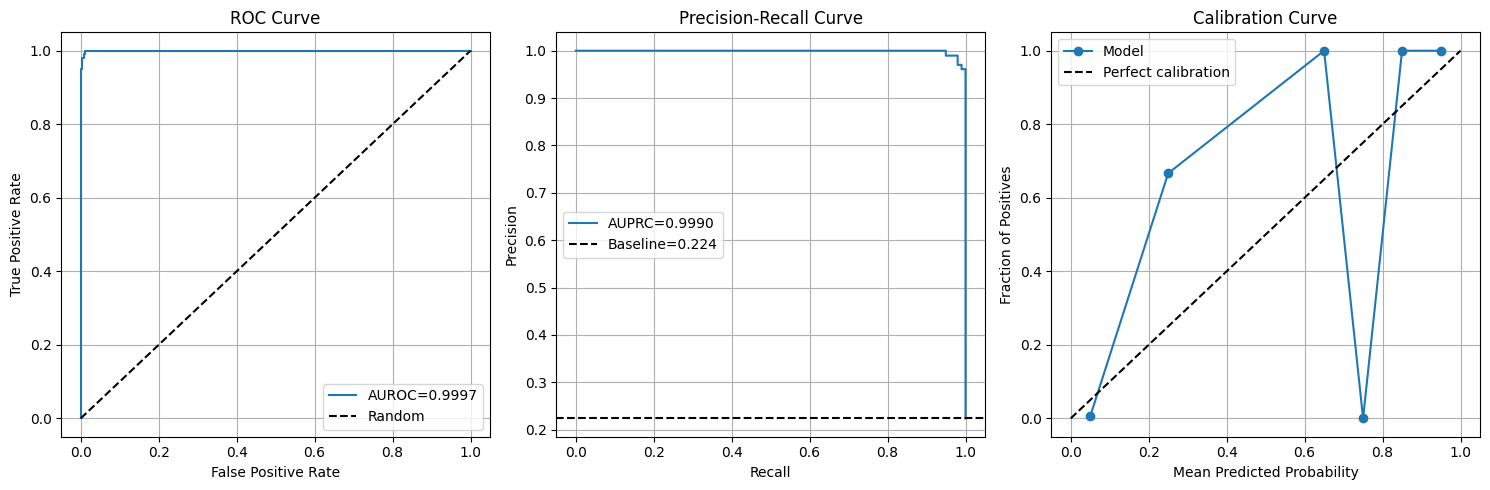

Curves saved to /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/test_report/ae_curves.png

次ステップ予測評価

モデル性能:
  MSE (global):    0.2847
  MSE (stepmean):  0.2872  ← 学習ログと同じ定義
  MAE (global):    0.3581
  RMSE (global):   0.5335

ナイーブBaseline（次=現在）:
  MSE (global):    2.7469
  MSE (stepmean):  2.7514
  MAE (global):    0.4774

改善率（vs Baseline）:
  MSE improvement: 89.6%
  MAE improvement: 25.0%

サンプル数: 219500 観測, 5709 ステップ

項目別MAE（上位10）:
  1. A/G: 0.4771
  2. S-K: 0.4746
  3. S-GLU: 0.4657
  4. Neutr: 0.4525
  5. Baso: 0.4452
  6. Mono: 0.4419
  7. PCT: 0.4372
  8. T.BIL: 0.4370
  9. S-CL: 0.4350
  10. S-Na: 0.4317

健全性チェック
Running intervention ablation test...

ラベルシャッフル検定: ✓ PASSED
  Shuffled AUROC: 0.5002 ± 0.0348 (expected: ~0.5)

介入無効化テスト:
  AUROC (with intervention):    0.9997
  AUROC (without intervention): 0.8951
  Drop: 0.1046
  Note: Large drop = model uses intervention info

レポート保存
Report saved to: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/test

In [24]:
# ============================================================
# テスト評価（詳細版）- 修正版
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)
from collections import defaultdict

# === 出力ディレクトリ ===
REPORT_DIR = os.path.join(CHECKPOINT_DIR, "test_report")
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"Report directory: {REPORT_DIR}")

# ============================================================
# 1. PyTorch 2.6対応のチェックポイントロード
# ============================================================
def load_checkpoint_compat(filepath, model, optimizer=None, map_location="cpu"):
    """PyTorch 2.6対応: weights_only=Falseで安全にロード"""
    checkpoint = torch.load(filepath, map_location=map_location, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded: {filepath} (epoch {checkpoint.get('epoch', '?')})")
    return checkpoint

# ============================================================
# 2. テストデータから予測・正解を収集（ナイーブbaseline追加）
# ============================================================
def collect_test_outputs(model, patient_data_dict, config, device):
    """
    テストデータ全患者を走査し、予測と正解を収集
    ナイーブbaseline（次=現在）も同時に収集
    """
    model.eval()

    ae_results = []  # [(pid, prob, label), ...]
    pred_results = []  # [(pid, pred, true, mask, baseline), ...]
    n_gap_resets = 0

    with torch.no_grad():
        for pid, pdata in patient_data_dict.items():
            n_obs = pdata["n_obs"]
            ae_labels_dict = pdata["ae_labels"]

            if n_obs < 2:
                continue

            times_week, features, masks, chemo, has_missing = _get_patient_tensors(pdata, device)

            h = model.h0.clone().to(device)
            c = torch.tensor(model.c0, dtype=torch.float, device=device)
            x_prev = features[0]

            for i in range(n_obs):
                x_curr = features[i]
                mask_curr = masks[i]
                a_i = int(chemo[i].item())
                dt = 0.0 if i == 0 else float((times_week[i] - times_week[i-1]).item())

                if i > 0 and has_missing[i]:
                    x_tilde = model.state_decoder(h)
                    x_input = mask_curr * x_curr + (1 - mask_curr) * x_tilde
                else:
                    x_input = x_curr

                x_prev_input = x_input if i == 0 else x_prev
                s_i, _ = model.encoder(x_input, x_prev_input, mask_curr, dt)
                s_token = model.proj_s(s_i)

                h_plus, c_plus = model.assimilation(h, c, s_i, a_i)

                if i < n_obs - 1:
                    delta_t = float((times_week[i + 1] - times_week[i]).item())

                    if delta_t > config.get("max_delta_week", 1e9):
                        n_gap_resets += 1
                        h = model.h0.clone().to(device)
                        c = torch.tensor(model.c0, device=device, dtype=torch.float)
                        x_prev = x_input.detach()
                        continue

                    pred, h_next, c_next = model.forward_interval(h_plus, c_plus, s_token, delta_t)

                    target = features[i + 1]
                    mask_next = masks[i + 1]

                    baseline = x_input.detach().cpu().numpy()

                    pred_results.append((
                        pid,
                        pred.detach().cpu().numpy(),
                        target.detach().cpu().numpy(),
                        mask_next.detach().cpu().numpy(),
                        baseline
                    ))

                    h, c = h_next, c_next
                else:
                    h, c = h_plus, c_plus

                if a_i == 1 and i in ae_labels_dict:
                    label, valid = ae_labels_dict[i]
                    if valid:
                        ae_logit = model.forward_ae(h_plus, c_plus, s_token)
                        ae_prob = torch.sigmoid(ae_logit).detach().cpu().item()
                        ae_results.append((pid, ae_prob, label))

                x_prev = x_input.detach()

    return {
        "ae_results": ae_results,
        "pred_results": pred_results,
        "n_gap_resets": n_gap_resets,
    }

# ============================================================
# 3. ECE計算
# ============================================================
# ============================================================
# 3. ECE計算
# ============================================================
def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error"""
    probs = np.array(probs)
    labels = np.array(labels)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (probs > bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc = labels[mask].mean()
        bin_conf = probs[mask].mean()
        ece += mask.sum() * np.abs(bin_acc - bin_conf)

    return ece / len(probs) if len(probs) > 0 else 0.0

# ============================================================
# 4. 二値分類の指標計算
# ============================================================
def compute_binary_metrics(probs, labels):
    """AEの二値分類指標を計算"""
    probs = np.array(probs)
    labels = np.array(labels).astype(int)

    results = {}

    if len(np.unique(labels)) < 2:
        results["auroc"] = None
        results["note"] = "Only one class present"
        return results

    results["auroc"] = roc_auc_score(labels, probs)
    results["auprc"] = average_precision_score(labels, probs)
    results["brier"] = brier_score_loss(labels, probs)
    results["bce"] = -np.mean(labels * np.log(probs + 1e-8) + (1 - labels) * np.log(1 - probs + 1e-8))
    results["ece"] = compute_ece(probs, labels)

    # 閾値0.5
    pred_05 = (probs >= 0.5).astype(int)
    results["thresh_05"] = {
        "accuracy": accuracy_score(labels, pred_05),
        "precision": precision_score(labels, pred_05, zero_division=0),
        "recall": recall_score(labels, pred_05, zero_division=0),
        "f1": f1_score(labels, pred_05, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, pred_05).tolist(),
    }

    # F1最大の閾値（oracle、参考値）
    best_f1, best_thresh = 0, 0.5
    for thresh in np.linspace(0, 1, 1001):
        pred_t = (probs >= thresh).astype(int)
        f1_t = f1_score(labels, pred_t, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_thresh = thresh

    pred_best = (probs >= best_thresh).astype(int)
    results["thresh_oracle_best_f1"] = {  # "oracle"を明記
        "threshold": best_thresh,
        "accuracy": accuracy_score(labels, pred_best),
        "precision": precision_score(labels, pred_best, zero_division=0),
        "recall": recall_score(labels, pred_best, zero_division=0),
        "f1": f1_score(labels, pred_best, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, pred_best).tolist(),
        "note": "Oracle threshold (optimized on test, for reference only)",
    }

    return results

# ============================================================
# 5. 回帰指標計算（global + stepmean + baseline）
# ============================================================
def compute_regression_metrics(pred_results):
    """次ステップ予測の回帰指標を計算（学習ログと同じ定義も含む）"""

    # === Global（全観測要素をフラットに） ===
    all_pred, all_true, all_mask, all_baseline = [], [], [], []

    for item in pred_results:
        pid, pred, true, mask, baseline = item
        all_pred.append(pred)
        all_true.append(true)
        all_mask.append(mask)
        all_baseline.append(baseline)

    all_pred = np.array(all_pred)
    all_true = np.array(all_true)
    all_mask = np.array(all_mask)
    all_baseline = np.array(all_baseline)

    mask_flat = all_mask.flatten() > 0.5
    pred_flat = all_pred.flatten()[mask_flat]
    true_flat = all_true.flatten()[mask_flat]
    baseline_flat = all_baseline.flatten()[mask_flat]

    mse_global = np.mean((pred_flat - true_flat) ** 2)
    mae_global = np.mean(np.abs(pred_flat - true_flat))
    rmse_global = np.sqrt(mse_global)

    # ナイーブbaseline
    mse_baseline = np.mean((baseline_flat - true_flat) ** 2)
    mae_baseline = np.mean(np.abs(baseline_flat - true_flat))
    rmse_baseline = np.sqrt(mse_baseline)

    # === Step-mean（学習ログと同じ定義） ===
    step_mse_list = []
    step_mse_baseline_list = []

    for item in pred_results:
        pid, pred, true, mask, baseline = item
        m = mask > 0.5
        if m.sum() == 0:
            continue
        step_mse = np.mean((pred[m] - true[m]) ** 2)
        step_mse_baseline = np.mean((baseline[m] - true[m]) ** 2)
        step_mse_list.append(step_mse)
        step_mse_baseline_list.append(step_mse_baseline)

    mse_stepmean = float(np.mean(step_mse_list)) if step_mse_list else None
    mse_stepmean_baseline = float(np.mean(step_mse_baseline_list)) if step_mse_baseline_list else None

    results = {
        # Global
        "mse_global": mse_global,
        "mae_global": mae_global,
        "rmse_global": rmse_global,
        # Step-mean（学習ログと同じ）
        "mse_stepmean": mse_stepmean,
        # Baseline
        "baseline_mse_global": mse_baseline,
        "baseline_mae_global": mae_baseline,
        "baseline_rmse_global": rmse_baseline,
        "baseline_mse_stepmean": mse_stepmean_baseline,
        # 改善率
        "improvement_mse": (mse_baseline - mse_global) / mse_baseline * 100 if mse_baseline > 0 else 0,
        "improvement_mae": (mae_baseline - mae_global) / mae_baseline * 100 if mae_baseline > 0 else 0,
        # サンプル数
        "n_samples": len(pred_flat),
        "n_steps": len(step_mse_list),
    }

    # 項目ごとのMAE（上位10件）
    n_features = all_pred.shape[1]
    feature_mae = []
    for f in range(n_features):
        f_mask = all_mask[:, f] > 0.5
        if f_mask.sum() > 0:
            f_mae = np.mean(np.abs(all_pred[:, f][f_mask] - all_true[:, f][f_mask]))
            feature_mae.append((f, f_mae))

    feature_mae.sort(key=lambda x: x[1], reverse=True)
    results["top10_feature_mae"] = feature_mae[:10]

    return results

# ============================================================
# 6. Bootstrap CI（患者単位）
# ============================================================
def bootstrap_ci_pid_level(ae_results, metric_fn, n_boot=1000, ci=0.95):
    """患者ID単位でブートストラップCI計算"""
    pid_to_events = defaultdict(list)
    for pid, prob, label in ae_results:
        pid_to_events[pid].append((prob, label))

    pids = list(pid_to_events.keys())
    n_pids = len(pids)

    if n_pids == 0:
        return None, None, None

    boot_values = []
    for _ in range(n_boot):
        sampled_pids = np.random.choice(pids, size=n_pids, replace=True)
        probs, labels = [], []
        for pid in sampled_pids:
            for prob, label in pid_to_events[pid]:
                probs.append(prob)
                labels.append(label)

        if len(np.unique(labels)) < 2:
            continue

        try:
            val = metric_fn(labels, probs)
            boot_values.append(val)
        except:
            continue

    if len(boot_values) < 100:
        return None, None, None

    alpha = (1 - ci) / 2
    lower = np.percentile(boot_values, alpha * 100)
    upper = np.percentile(boot_values, (1 - alpha) * 100)
    mean = np.mean(boot_values)

    return mean, lower, upper

# ============================================================
# 7. 曲線描画
# ============================================================
def plot_curves(probs, labels, save_dir):
    """ROC曲線、PR曲線、Calibration curveを描画・保存"""
    probs = np.array(probs)
    labels = np.array(labels)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ROC曲線
    fpr, tpr, _ = roc_curve(labels, probs)
    auroc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, label=f"AUROC={auroc:.4f}")
    axes[0].plot([0, 1], [0, 1], 'k--', label="Random")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(True)

    # PR曲線
    precision, recall, _ = precision_recall_curve(labels, probs)
    auprc = average_precision_score(labels, probs)
    baseline = labels.mean()
    axes[1].plot(recall, precision, label=f"AUPRC={auprc:.4f}")
    axes[1].axhline(baseline, color='k', linestyle='--', label=f"Baseline={baseline:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(True)

    # Calibration curve
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_accs = [], []
    for i in range(n_bins):
        mask = (probs > bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        if mask.sum() > 0:
            bin_centers.append((bin_boundaries[i] + bin_boundaries[i + 1]) / 2)
            bin_accs.append(labels[mask].mean())

    axes[2].plot(bin_centers, bin_accs, 'o-', label="Model")
    axes[2].plot([0, 1], [0, 1], 'k--', label="Perfect calibration")
    axes[2].set_xlabel("Mean Predicted Probability")
    axes[2].set_ylabel("Fraction of Positives")
    axes[2].set_title("Calibration Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "ae_curves.png"), dpi=150)
    plt.show()
    print(f"Curves saved to {save_dir}/ae_curves.png")

# ============================================================
# 8. 健全性チェック
# ============================================================
def run_sanity_checks(probs, labels, model, test_data, config, device):
    """健全性チェック"""
    probs = np.array(probs)
    labels = np.array(labels)

    results = {}

    # 1. ラベルシャッフル検定
    n_shuffle = 100
    shuffled_aurocs = []
    for _ in range(n_shuffle):
        shuffled_labels = np.random.permutation(labels)
        if len(np.unique(shuffled_labels)) >= 2:
            try:
                auroc_s = roc_auc_score(shuffled_labels, probs)
                shuffled_aurocs.append(auroc_s)
            except:
                pass

    if len(shuffled_aurocs) > 0:
        results["label_shuffle"] = {
            "mean_auroc": float(np.mean(shuffled_aurocs)),
            "std_auroc": float(np.std(shuffled_aurocs)),
            "expected": 0.5,
            "passed": abs(np.mean(shuffled_aurocs) - 0.5) < 0.1,
        }

    # 2. 介入無効化テスト
    print("Running intervention ablation test...")
    model.eval()
    ae_results_no_intervention = []
    n_gap_resets_no_intervention = 0

    with torch.no_grad():
        for pid, pdata in test_data.items():
            n_obs = pdata["n_obs"]
            ae_labels_dict = pdata["ae_labels"]

            if n_obs < 2:
                continue

            times_week, features, masks, chemo, has_missing = _get_patient_tensors(pdata, device)

            h = model.h0.clone().to(device)
            c = torch.tensor(model.c0, dtype=torch.float, device=device)
            x_prev = features[0]

            for i in range(n_obs):
                x_curr = features[i]
                mask_curr = masks[i]
                a_i_real = int(chemo[i].item())
                a_i = 0
                dt = 0.0 if i == 0 else float((times_week[i] - times_week[i-1]).item())

                if i > 0 and has_missing[i]:
                    x_tilde = model.state_decoder(h)
                    x_input = mask_curr * x_curr + (1 - mask_curr) * x_tilde
                else:
                    x_input = x_curr

                x_prev_input = x_input if i == 0 else x_prev
                s_i, _ = model.encoder(x_input, x_prev_input, mask_curr, dt)
                s_token = model.proj_s(s_i)

                h_plus, c_plus = model.assimilation(h, c, s_i, a_i)

                if i < n_obs - 1:
                    delta_t = float((times_week[i + 1] - times_week[i]).item())
                    if delta_t > config.get("max_delta_week", 1e9):
                        n_gap_resets_no_intervention += 1
                        h = model.h0.clone().to(device)
                        c = torch.tensor(model.c0, device=device, dtype=torch.float)
                        x_prev = x_input.detach()
                        continue
                    _, h_next, c_next = model.forward_interval(h_plus, c_plus, s_token, delta_t)
                    h, c = h_next, c_next
                else:
                    h, c = h_plus, c_plus

                if a_i_real == 1 and i in ae_labels_dict:
                    label, valid = ae_labels_dict[i]
                    if valid:
                        ae_logit = model.forward_ae(h_plus, c_plus, s_token)
                        ae_prob = torch.sigmoid(ae_logit).detach().cpu().item()
                        ae_results_no_intervention.append((pid, ae_prob, label))

                x_prev = x_input.detach()

    if len(ae_results_no_intervention) > 0:
        probs_no_int = [r[1] for r in ae_results_no_intervention]
        labels_no_int = [r[2] for r in ae_results_no_intervention]

        if len(np.unique(labels_no_int)) >= 2:
            auroc_no_int = roc_auc_score(labels_no_int, probs_no_int)
            auroc_original = roc_auc_score(labels, probs)
            drop = auroc_original - auroc_no_int

            results["intervention_ablation"] = {
                "auroc_with_intervention": float(auroc_original),
                "auroc_without_intervention": float(auroc_no_int),
                "auroc_drop": float(drop),
                "n_gap_resets_no_intervention": int(n_gap_resets_no_intervention),
                "note": "Large drop = model uses intervention info" if drop > 0.05 else "Small drop = possible leakage or intervention not used",
            }

    return results

# ============================================================
# 9. メイン実行
# ============================================================
# ============================================================
# 9. メイン実行
# ============================================================
print("=" * 60)
print("テスト評価（詳細版）")
print("=" * 60)

# チェックポイントロード
best_checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{best_epoch:03d}.pt")
if os.path.exists(best_checkpoint_path):
    checkpoint = load_checkpoint_compat(best_checkpoint_path, model, map_location=device)
else:
    print(f"Warning: Best checkpoint not found at {best_checkpoint_path}")
    print("Using current model state")

model.to(device)

# テスト出力を収集
print("\nCollecting test outputs...")
test_outputs = collect_test_outputs(model, test_data, CONFIG, device)
ae_results = test_outputs["ae_results"]
pred_results = test_outputs["pred_results"]
test_n_resets = test_outputs.get("n_gap_resets", 0)

print(f"  AE samples: {len(ae_results)}")
print(f"  Prediction samples: {len(pred_results)}")
print(f"  Gap resets (test): {test_n_resets}")

# === AE指標 ===
print("\n" + "=" * 60)
print("AE（有害事象）評価")
print("=" * 60)

ae_probs = [r[1] for r in ae_results]
ae_labels = [r[2] for r in ae_results]

ae_metrics = compute_binary_metrics(ae_probs, ae_labels)

print(f"\n基本指標:")
if ae_metrics.get('auroc') is not None:
    print(f"  AUROC:  {ae_metrics['auroc']:.4f}")
    print(f"  AUPRC:  {ae_metrics['auprc']:.4f}")
    print(f"  BCE:    {ae_metrics['bce']:.4f}")
    print(f"  Brier:  {ae_metrics['brier']:.4f}")
    print(f"  ECE:    {ae_metrics['ece']:.4f}")
else:
    print("  N/A (single class)")

if "thresh_05" in ae_metrics:
    t05 = ae_metrics["thresh_05"]
    print(f"\n閾値=0.5:")
    print(f"  Accuracy:  {t05['accuracy']:.4f}")
    print(f"  Precision: {t05['precision']:.4f}")
    print(f"  Recall:    {t05['recall']:.4f}")
    print(f"  F1:        {t05['f1']:.4f}")
    print(f"  Confusion Matrix: {t05['confusion_matrix']}")

if "thresh_oracle_best_f1" in ae_metrics:
    tbest = ae_metrics["thresh_oracle_best_f1"]
    print(f"\n閾値={tbest['threshold']:.3f}（Oracle、参考値）:")
    print(f"  Accuracy:  {tbest['accuracy']:.4f}")
    print(f"  Precision: {tbest['precision']:.4f}")
    print(f"  Recall:    {tbest['recall']:.4f}")
    print(f"  F1:        {tbest['f1']:.4f}")

# Bootstrap CI
print("\nBootstrap CI (95%, patient-level)...")
auroc_mean, auroc_lower, auroc_upper = bootstrap_ci_pid_level(
    ae_results, roc_auc_score, n_boot=1000
)
auprc_mean, auprc_lower, auprc_upper = bootstrap_ci_pid_level(
    ae_results, average_precision_score, n_boot=1000
)

ci_results = {}
if auroc_mean is not None:
    print(f"  AUROC: {auroc_mean:.4f} [{auroc_lower:.4f}, {auroc_upper:.4f}]")
    ci_results["auroc_ci"] = {"mean": auroc_mean, "lower": auroc_lower, "upper": auroc_upper}
if auprc_mean is not None:
    print(f"  AUPRC: {auprc_mean:.4f} [{auprc_lower:.4f}, {auprc_upper:.4f}]")
    ci_results["auprc_ci"] = {"mean": auprc_mean, "lower": auprc_lower, "upper": auprc_upper}

# 曲線描画
if ae_metrics.get("auroc") is not None:
    print("\nPlotting curves...")
    plot_curves(ae_probs, ae_labels, REPORT_DIR)

# === 予測指標 ===
print("\n" + "=" * 60)
print("次ステップ予測評価")
print("=" * 60)

reg_metrics = compute_regression_metrics(pred_results)

print(f"\nモデル性能:")
print(f"  MSE (global):    {reg_metrics['mse_global']:.4f}")
print(f"  MSE (stepmean):  {reg_metrics['mse_stepmean']:.4f}  ← 学習ログと同じ定義")
print(f"  MAE (global):    {reg_metrics['mae_global']:.4f}")
print(f"  RMSE (global):   {reg_metrics['rmse_global']:.4f}")

print(f"\nナイーブBaseline（次=現在）:")
print(f"  MSE (global):    {reg_metrics['baseline_mse_global']:.4f}")
print(f"  MSE (stepmean):  {reg_metrics['baseline_mse_stepmean']:.4f}")
print(f"  MAE (global):    {reg_metrics['baseline_mae_global']:.4f}")

print(f"\n改善率（vs Baseline）:")
print(f"  MSE improvement: {reg_metrics['improvement_mse']:.1f}%")
print(f"  MAE improvement: {reg_metrics['improvement_mae']:.1f}%")

print(f"\nサンプル数: {reg_metrics['n_samples']} 観測, {reg_metrics['n_steps']} ステップ")

# feature_colsが存在するか確認
try:
    feat_cols = feature_cols
except NameError:
    feat_cols = None

print(f"\n項目別MAE（上位10）:")
for rank, (feat_idx, mae) in enumerate(reg_metrics["top10_feature_mae"], 1):
    if feat_cols and feat_idx < len(feat_cols):
        feat_name = feat_cols[feat_idx]
    else:
        feat_name = f"feat_{feat_idx}"
    print(f"  {rank}. {feat_name}: {mae:.4f}")

# === 健全性チェック ===
print("\n" + "=" * 60)
print("健全性チェック")
print("=" * 60)

sanity_results = run_sanity_checks(ae_probs, ae_labels, model, test_data, CONFIG, device)

if "label_shuffle" in sanity_results:
    ls = sanity_results["label_shuffle"]
    status = "✓ PASSED" if ls["passed"] else "✗ FAILED"
    print(f"\nラベルシャッフル検定: {status}")
    print(f"  Shuffled AUROC: {ls['mean_auroc']:.4f} ± {ls['std_auroc']:.4f} (expected: ~0.5)")

if "intervention_ablation" in sanity_results:
    ia = sanity_results["intervention_ablation"]
    print(f"\n介入無効化テスト:")
    print(f"  AUROC (with intervention):    {ia['auroc_with_intervention']:.4f}")
    print(f"  AUROC (without intervention): {ia['auroc_without_intervention']:.4f}")
    print(f"  Drop: {ia['auroc_drop']:.4f}")
    print(f"  Note: {ia['note']}")

# === レポート保存 ===
print("\n" + "=" * 60)
print("レポート保存")
print("=" * 60)

report = {
    "best_epoch": best_epoch,
    "ae_metrics": {k: v for k, v in ae_metrics.items() if v is not None},
    "ae_bootstrap_ci": ci_results,
    "regression_metrics": {
        "mse_global": reg_metrics["mse_global"],
        "mse_stepmean": reg_metrics["mse_stepmean"],
        "mae_global": reg_metrics["mae_global"],
        "rmse_global": reg_metrics["rmse_global"],
        "baseline_mse_global": reg_metrics["baseline_mse_global"],
        "baseline_mse_stepmean": reg_metrics["baseline_mse_stepmean"],
        "improvement_mse_pct": reg_metrics["improvement_mse"],
        "improvement_mae_pct": reg_metrics["improvement_mae"],
        "n_samples": reg_metrics["n_samples"],
        "n_steps": reg_metrics["n_steps"],
    },
    "sanity_checks": sanity_results,
    "n_gap_resets_test": int(test_n_resets),
    "halflife": model.get_halflife(),
}

report_path = os.path.join(REPORT_DIR, "test_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2, default=str)
print(f"Report saved to: {report_path}")

print("\n" + "=" * 60)
print("テスト評価完了")
print("=" * 60)

---
## セル24: 学習曲線の可視化
---

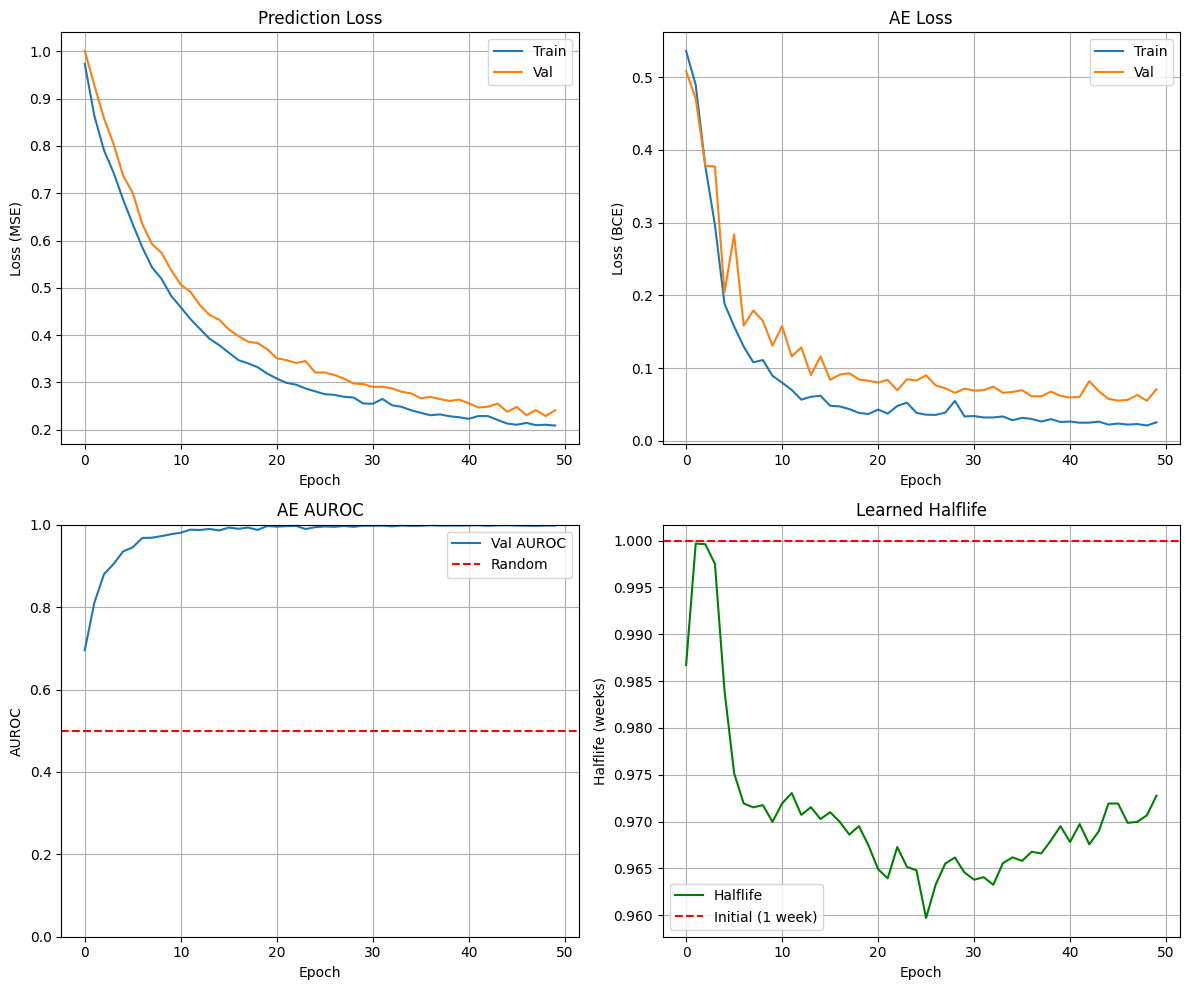

学習曲線を保存: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/learning_curves_v3_fast_simplext.png


In [25]:
# [MODIFIED] 学習曲線の可視化
# [FIX-v2.5] 半減期の推移を追加

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 予測損失
axes[0, 0].plot(history["train_loss_pred"], label="Train")
axes[0, 0].plot(history["val_loss_pred"], label="Val")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss (MSE)")
axes[0, 0].set_title("Prediction Loss")
axes[0, 0].legend()
axes[0, 0].grid(True)

# AE損失
axes[0, 1].plot(history["train_loss_ae"], label="Train")
axes[0, 1].plot(history["val_loss_ae"], label="Val")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss (BCE)")
axes[0, 1].set_title("AE Loss")
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUROC
val_auroc_clean = [v if v is not None else 0.5 for v in history["val_auroc"]]
axes[1, 0].plot(val_auroc_clean, label="Val AUROC")
axes[1, 0].axhline(y=0.5, color='r', linestyle='--', label="Random")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("AUROC")
axes[1, 0].set_title("AE AUROC")
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_ylim([0, 1])

# [FIX-v2.5] 半減期の推移
axes[1, 1].plot(history["halflife"], label="Halflife", color='green')
axes[1, 1].axhline(y=1.0, color='r', linestyle='--', label="Initial (1 week)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Halflife (weeks)")
axes[1, 1].set_title("Learned Halflife")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "learning_curves_v3_fast_simplext.png"), dpi=150)
plt.show()

print(f"学習曲線を保存: {os.path.join(CHECKPOINT_DIR, 'learning_curves_v3_fast_simplext.png')}")

---
## セル25: 履歴の保存
---

In [26]:
# 履歴の保存
history_json = {
    k: [str(v) if v is None else v for v in vals]
    for k, vals in history.items()
}
history_path = os.path.join(CHECKPOINT_DIR, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history_json, f, indent=2)
print(f"学習履歴を保存: {history_path}")

# 新しい変数名に対応
summary = {
    "version": "v3_fast_simplext",
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "test_loss_pred": reg_metrics["mse_stepmean"],  # 学習ログと同じ定義
    "test_loss_ae": ae_metrics.get("bce", None),
    "test_auroc": ae_metrics.get("auroc", None),
    "test_auprc": ae_metrics.get("auprc", None),
    "test_brier": ae_metrics.get("brier", None),
    "test_ece": ae_metrics.get("ece", None),
    "final_halflife": model.get_halflife(),
    "config": CONFIG,
}
summary_path = os.path.join(CHECKPOINT_DIR, "final_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"最終サマリを保存: {summary_path}")

学習履歴を保存: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/training_history.json
最終サマリを保存: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/final_summary.json


In [27]:
# ==============================================================================
# チェックポイントからモデルをロード
# ==============================================================================

# チェックポイントのパス（最新 or ベストエポック）
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pt")
# または: CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_047.pt")

# モデルを初期化
model = IntegratedModel(CONFIG, F).to(device)

# チェックポイントをロード（PyTorch 2.6対応）
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"チェックポイントをロード: {CHECKPOINT_PATH}")
print(f"  エポック: {checkpoint.get('epoch', '?')}")
print(f"  メトリクス: {checkpoint.get('metrics', '?')}")

チェックポイントをロード: /content/drive/MyDrive/世界モデル_最終課題/checkpoints_v3_fast_simplext/checkpoint_latest.pt
  エポック: 50
  メトリクス: {'train_loss_pred': 0.20885014896555407, 'train_loss_ae': 0.02539057603740466, 'val_loss_pred': 0.24096895556500617, 'val_loss_ae': 0.07084329488147945, 'val_auroc': np.float64(0.9984332158245202), 'halflife': 0.9727692604064941, 'train_n_resets': 115, 'val_n_resets': 19}


In [ ]:
# ==============================================================================
# Attention行列可視化（v3）
# ==============================================================================

print("v3ではCross-Time Attentionを使わないため、Attention行列Aの可視化は対象外です。")
A_list = []


In [ ]:
# Attention指標（v3）
if len(A_list) == 0:
    print("v3ではAttention行列が存在しないため、エントロピー等の指標は算出しません。")
else:
    A_mean = np.mean(A_list, axis=0)
    F_items = A_mean.shape[0]
    row_entropy = -np.sum(A_mean * np.log(A_mean + 1e-10), axis=1)
    print(f"平均エントロピー: {row_entropy.mean():.4f}")
    print(f"理想（集中）: 0, 最悪（一様）: {np.log(F_items):.4f}")
